# **Лабораторная 3: Временные ряды**

Выполнили студент гр. J3212:
* Фёдоров Егор Павлович


# **Постановка задачи**

Дан файл `sell.csv` с временными рядами продаж

Цели:

1. Реализовать несколько методов фильтрации временных рядов
2. Применить фильтры к данным продаж и качественно сравнить результат
3. Проанализировать временной ряд: корреляции, периодичность, тренды и другие характеристики
4. Для hard-части дополнительно рассмотреть данные с несколькими датчиками и сделать выводы по фильтрации

В работе реализованы четыре метода:

1. экспоненциальное сглаживание
2. одномерный фильтр Калмана
3. фильтр Савицкого–Голея
4. адаптивный LMS-фильтр как hard-часть по фильтрации

In [38]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# **1. Загрузка и разбор `sell.csv`**

Файл устроен не как обычная таблица: в одной строке лежат заголовки всех 60 вариантов, а дальше для каждого дня подряд идут блоки по 6 колонок:

* `мыло`
* `порошок`
* `средство`
* `краска`
* `пена`
* `прибыль`

Поэтому удобнее считать файл как таблицу без нормального заголовка и затем вручную вырезать нужный блок из 6 колонок

In [39]:
SELL_PATH = Path("sell.csv")

raw_sell = pd.read_csv(SELL_PATH, sep=";", header=None, encoding="cp1251", dtype=str)
raw_sell.shape


(53, 361)

In [40]:
raw_sell


,0,1,2,3,4,5,6,7,8,9,...,351,352,353,354,355,356,357,358,359,360
0,NaN,Вариант 1,NaN,NaN,NaN,NaN,NaN,Вариант 2,NaN,NaN,...,NaN,NaN,NaN,NaN,Вариант 60,NaN,NaN,NaN,NaN,NaN
1,Дни продаж,мыло,порошок,средство,краска,пена,прибыль,мыло,порошок,средство,...,средство,краска,пена,прибыль,мыло,порошок,средство,краска,пена,прибыль
2,NaN,шт.,шт.,шт.,шт.,шт.,тыс. руб.,шт.,шт.,шт.,...,шт.,шт.,шт.,тыс. руб.,шт.,шт.,шт.,шт.,шт.,тыс. руб.
3,1,87,25,22,42,22,"26,867",119,17,22,...,18,43,19,"26,926",103,26,18,41,21,"28,787"
4,2,101,14,20,41,20,"28,413",82,19,20,...,25,43,22,"29,674",90,27,21,42,18,"26,369"
5,3,108,20,24,43,18,"27,782",110,21,26,...,15,44,25,"25,526",117,28,21,45,20,"29,841"
6,4,79,17,18,42,22,"25,538",123,23,25,...,23,46,21,"26,962",109,25,25,44,20,"28,556"
7,5,100,19,23,42,19,"27,615",74,18,19,...,21,40,21,"27,362",72,17,17,45,22,"25,585"
8,6,108,19,23,42,21,"27,951",122,22,26,...,24,44,21,"27,884",118,16,24,44,19,"29,653"
9,7,103,14,25,42,19,"29,007",104,23,23,...,21,41,22,"27,653",105,27,25,43,20,"27,403"


In [41]:
def to_number(column):
    column = column.astype(str).str.replace(",", ".", regex=False).str.strip()
    return pd.to_numeric(column, errors="coerce")

data = raw_sell.iloc[3:].reset_index(drop=True)
days = to_number(data.iloc[:, 0]).astype(int)

product_columns = ["мыло", "порошок", "средство", "краска", "пена"]
value_columns = product_columns + ["прибыль"]

variants = {}

for variant in range(1, 61):
    start = 1 + (variant - 1) * 6
    block = data.iloc[:, start:start + 6].copy()
    block.columns = value_columns

    for column in value_columns:
        block[column] = to_number(block[column])

    block.insert(0, "день", days)
    variants[variant] = block

pd.DataFrame({
    "количество вариантов": [len(variants)],
    "дней в каждом варианте": [len(variants[1])],
    "колонок в варианте": [len(variants[1].columns)],
})


,количество вариантов,дней в каждом варианте,колонок в варианте
0,60,50,7


## Выбор варианта

По условию вариант считается как:

$$
variant = (ISU_1 + ISU_2) \bmod 60
$$


In [42]:
ISU_NUMBERS = [467866]
MANUAL_VARIANT = 1

if len(ISU_NUMBERS) > 0:
    VARIANT = sum(ISU_NUMBERS) % 60
    if VARIANT == 0:
        VARIANT = 60
else:
    VARIANT = MANUAL_VARIANT

selected = variants[VARIANT].copy()

print("Используемый вариант:", VARIANT)


Используемый вариант: 46


In [43]:
selected.head(10)


,день,мыло,порошок,средство,краска,пена,прибыль
0,1,85,18,19,42,21,26.481
1,2,116,26,24,39,20,28.320
2,3,115,24,22,42,21,27.408
3,4,86,21,20,45,17,24.630
4,5,119,14,25,46,19,28.410
5,6,87,16,21,42,20,26.176
6,7,100,24,18,40,21,27.619
7,8,99,11,26,39,17,27.398
8,9,122,16,25,44,20,29.055
9,10,74,18,19,47,23,26.029


## Первичный вид данных

Сначала посмотрим на исходные ряды без фильтрации. Это важно, потому что фильтр не должен полностью менять смысл данных: его задача - убрать случайные скачки и сохранить общий профиль динамики

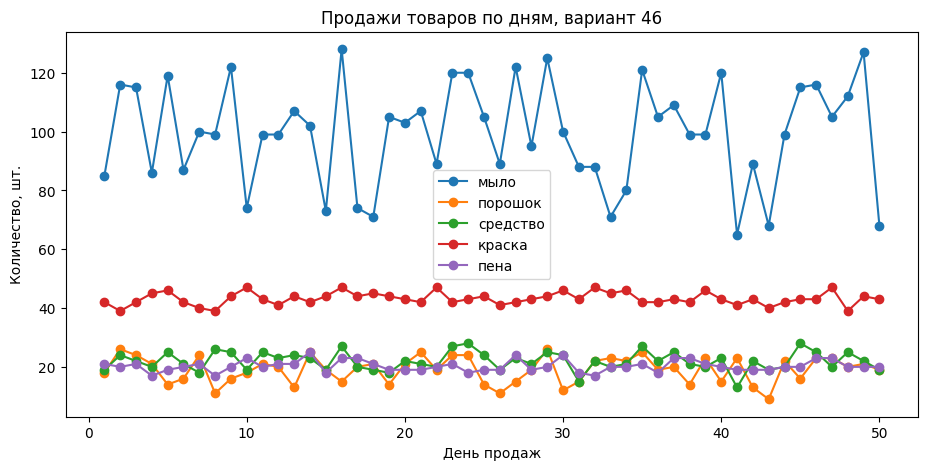

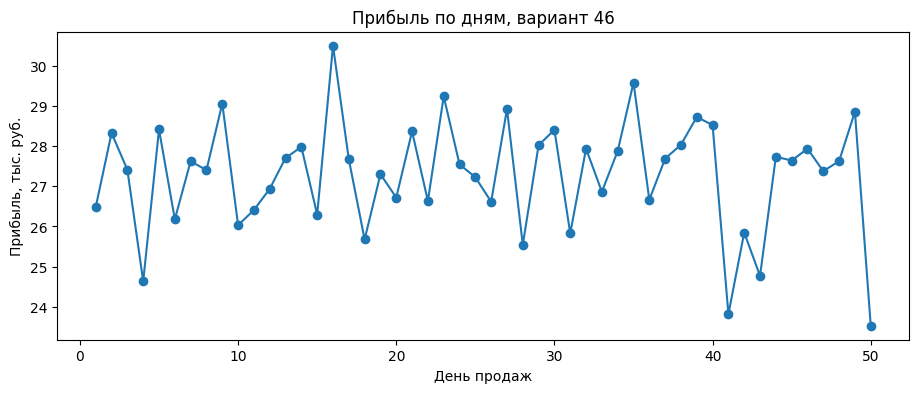

In [44]:
plt.figure(figsize=(11, 5))
for column in product_columns:
    plt.plot(selected["день"], selected[column], marker="o", label=column)

plt.title(f"Продажи товаров по дням, вариант {VARIANT}")
plt.xlabel("День продаж")
plt.ylabel("Количество, шт.")
plt.legend()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(selected["день"], selected["прибыль"], marker="o")
plt.title(f"Прибыль по дням, вариант {VARIANT}")
plt.xlabel("День продаж")
plt.ylabel("Прибыль, тыс. руб.")
plt.show()


# **2. Реализация методов фильтрации**

Фильтрация нужна для того, чтобы отделить полезную динамику временного ряда от локального шума

Здесь есть важный баланс:

* если сглаживать слишком слабо, шум почти не исчезнет
* если сглаживать слишком сильно, исчезнут реальные пики и провалы продаж
* хороший фильтр должен уменьшать резкие случайные колебания, но не превращать ряд в почти прямую линию

## 2.1. Экспоненциальное сглаживание

Экспоненциальное сглаживание строит новое значение как смесь текущего наблюдения и предыдущего сглаженного значения:

$$
\hat y_t = \alpha y_t + (1 - \alpha)\hat y_{t-1}
$$

Если `alpha` большое, фильтр сильнее реагирует на новые точки. Если `alpha` маленькое, ряд получается более гладким, но появляется инерционность

In [45]:
def exponential_smoothing(values, alpha=0.35):
    values = np.array(values, dtype=float)
    result = np.zeros(len(values))
    result[0] = values[0]

    for i in range(1, len(values)):
        result[i] = alpha * values[i] + (1 - alpha) * result[i - 1]

    return result


## 2.2. Одномерный фильтр Калмана

Фильтр Калмана удобно использовать, когда наблюдение шумное, но за ним скрыто некоторое истинное состояние

В этой работе берётся простая модель локального уровня:

$$
x_t = x_{t-1} + w_t
\qquad
z_t = x_t + v_t
$$

Здесь `z_t` - наблюдаемая прибыль, `x_t` - скрытое сглаженное состояние, `w_t` - шум процесса, `v_t` - шум измерения. Такой вариант подходит для короткого ряда, потому что не требует сложной модели сезонности

In [46]:
def kalman_filter_1d(values, process_variance=0.04, measurement_variance=None):
    values = np.array(values, dtype=float)

    if measurement_variance is None:
        measurement_variance = np.var(np.diff(values))
        if measurement_variance <= 0:
            measurement_variance = 1.0

    result = np.zeros(len(values))
    estimate = values[0]
    error = 1.0

    for i in range(len(values)):
        error = error + process_variance

        kalman_gain = error / (error + measurement_variance)
        estimate = estimate + kalman_gain * (values[i] - estimate)
        error = (1 - kalman_gain) * error

        result[i] = estimate

    return result


## 2.3. Фильтр Савицкого–Голея

Фильтр Савицкого–Голея сглаживает ряд не просто средним, а локальным полиномом. В маленьком окне вокруг каждой точки он подбирает полином небольшой степени и берёт значение этого полинома как сглаженную точку

Плюс такого подхода в том, что он лучше сохраняет форму пиков, чем обычное скользящее среднее

In [47]:
def savgol_smoothing(values, window_length=7, polyorder=2):
    values = np.array(values, dtype=float)

    if len(values) < 3:
        return values.copy()

    if window_length > len(values):
        window_length = len(values)

    if window_length % 2 == 0:
        window_length = window_length - 1

    if polyorder >= window_length:
        polyorder = window_length - 1

    return savgol_filter(values, window_length=window_length, polyorder=polyorder, mode="interp")


## 2.4. Адаптивный LMS-фильтр

LMS-фильтр относится к адаптивным методам. Он не использует фиксированные коэффициенты на всём ряду, а постепенно подстраивает веса так, чтобы предсказывать текущую точку по нескольким предыдущим

В этой работе LMS используется как авторегрессионный сглаживатель: он берёт несколько прошлых значений ряда и строит прогноз текущего значения. Если ряд меняет поведение, веса фильтра тоже постепенно меняются

In [48]:
def lms_adaptive_filter(values, n_taps=4, mu=0.65):
    values = np.array(values, dtype=float)

    if len(values) <= n_taps:
        return values.copy()

    weights = np.zeros(n_taps)
    weights[0] = 1.0
    result = values.copy()

    for i in range(n_taps, len(values)):
        last_values = values[i - n_taps:i][::-1]

        prediction = np.dot(weights, last_values)
        error = values[i] - prediction

        # Нормировка нужна, чтобы веса не менялись слишком резко.
        normalizer = np.dot(last_values, last_values) + 1e-8
        weights = weights + mu * error * last_values / normalizer

        result[i] = prediction

    result[:n_taps] = exponential_smoothing(values[:n_taps], alpha=0.5)
    return result


# **3. Сравнение фильтров на данных продаж**

Для сравнения возьмём ряд прибыли. Это самый удобный целевой ряд, потому что он агрегирует результат продаж всех товаров и выражен в деньгах

После этого применим те же фильтры ко всем колонкам, чтобы показать, что код работает не только для прибыли

In [49]:
profit = selected["прибыль"].to_numpy(dtype=float)

def apply_all_filters(values):
    values = np.array(values, dtype=float)

    filtered = pd.DataFrame()
    filtered["исходный ряд"] = values
    filtered["экспоненциальное сглаживание"] = exponential_smoothing(values, alpha=0.35)
    filtered["Калман"] = kalman_filter_1d(values, process_variance=0.04)
    filtered["Савицкий–Голей"] = savgol_smoothing(values, window_length=7, polyorder=2)
    filtered["LMS"] = lms_adaptive_filter(values, n_taps=4, mu=0.65)

    return filtered


profit_filtered = apply_all_filters(profit)
profit_filtered.insert(0, "день", selected["день"].values)

profit_filtered.head()


,день,исходный ряд,экспоненциальное сглаживание,Калман,Савицкий–Голей,LMS
0,1,26.481,26.481000,26.481000,27.261976,26.481000
1,2,28.320,27.124650,26.790247,26.997143,27.400500
2,3,27.408,27.223823,26.883305,26.840071,27.404250
3,4,24.630,26.315985,26.572780,26.790762,26.017125
4,5,28.410,27.048890,26.808245,26.540524,24.630000


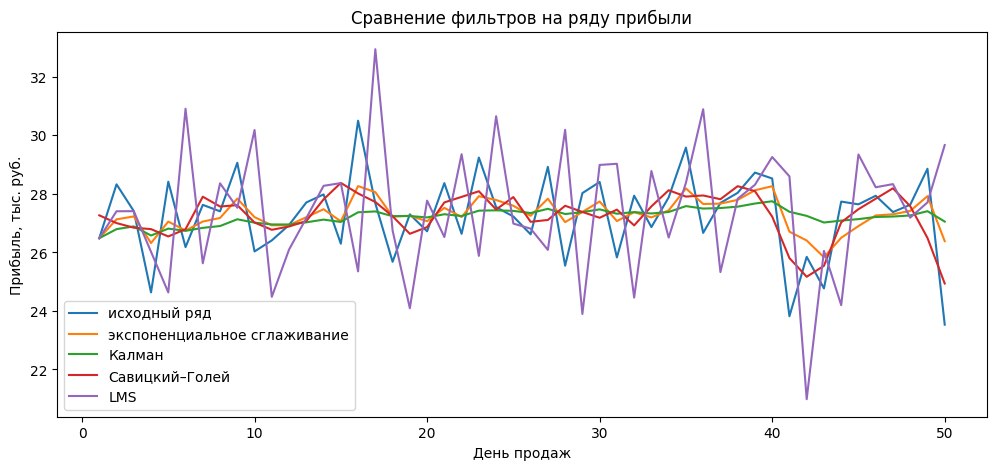

In [50]:
plt.figure(figsize=(12, 5))

for column in profit_filtered.columns:
    if column == "день":
        continue

    plt.plot(profit_filtered["день"], profit_filtered[column], label=column)

plt.title("Сравнение фильтров на ряду прибыли")
plt.xlabel("День продаж")
plt.ylabel("Прибыль, тыс. руб.")
plt.legend()
plt.show()


## Численное сравнение

Так как у нас нет отдельного «истинного» гладкого ряда, нельзя честно посчитать ошибку относительно ground truth. Поэтому сравниваем фильтры по косвенным характеристикам

* `std(diff)` - стандартное отклонение первых разностей. Чем меньше, тем ряд глаже
* `снижение шероховатости` - насколько фильтр уменьшил `std(diff)` относительно исходного ряда
* `corr с исходным рядом` - насколько фильтр сохранил форму исходных данных
* `MAE к исходному ряду` - насколько сильно фильтр в среднем отодвинулся от наблюдений

Хороший результат для этой задачи - заметно снизить шероховатость, но не потерять корреляцию с исходным рядом

In [51]:
def roughness(values):
    values = np.array(values, dtype=float)
    return np.std(np.diff(values), ddof=1)


def compare_filters(filtered_frame):
    original = filtered_frame["исходный ряд"].to_numpy(dtype=float)
    original_roughness = roughness(original)

    rows = []

    for column in filtered_frame.columns:
        if column == "день":
            continue

        values = filtered_frame[column].to_numpy(dtype=float)
        values_roughness = roughness(values)

        rows.append({
            "метод": column,
            "std(diff)": values_roughness,
            "снижение шероховатости, %": 100 * (1 - values_roughness / original_roughness),
            "corr с исходным рядом": np.corrcoef(original, values)[0, 1],
            "MAE к исходному ряду": mean_absolute_error(original, values),
        })

    return pd.DataFrame(rows).sort_values("снижение шероховатости, %", ascending=False)


filter_metrics = compare_filters(profit_filtered)
filter_metrics


,метод,std(diff),"снижение шероховатости, %",corr с исходным рядом,MAE к исходному ряду
2,Калман,0.149838,92.889272,0.366533,1.017563
1,экспоненциальное сглаживание,0.567379,73.074483,0.776568,0.804508
3,Савицкий–Голей,0.601257,71.466756,0.558709,0.924486
0,исходный ряд,2.107217,0.000000,1.000000,0.000000
4,LMS,3.546210,-68.288815,-0.140218,2.174081


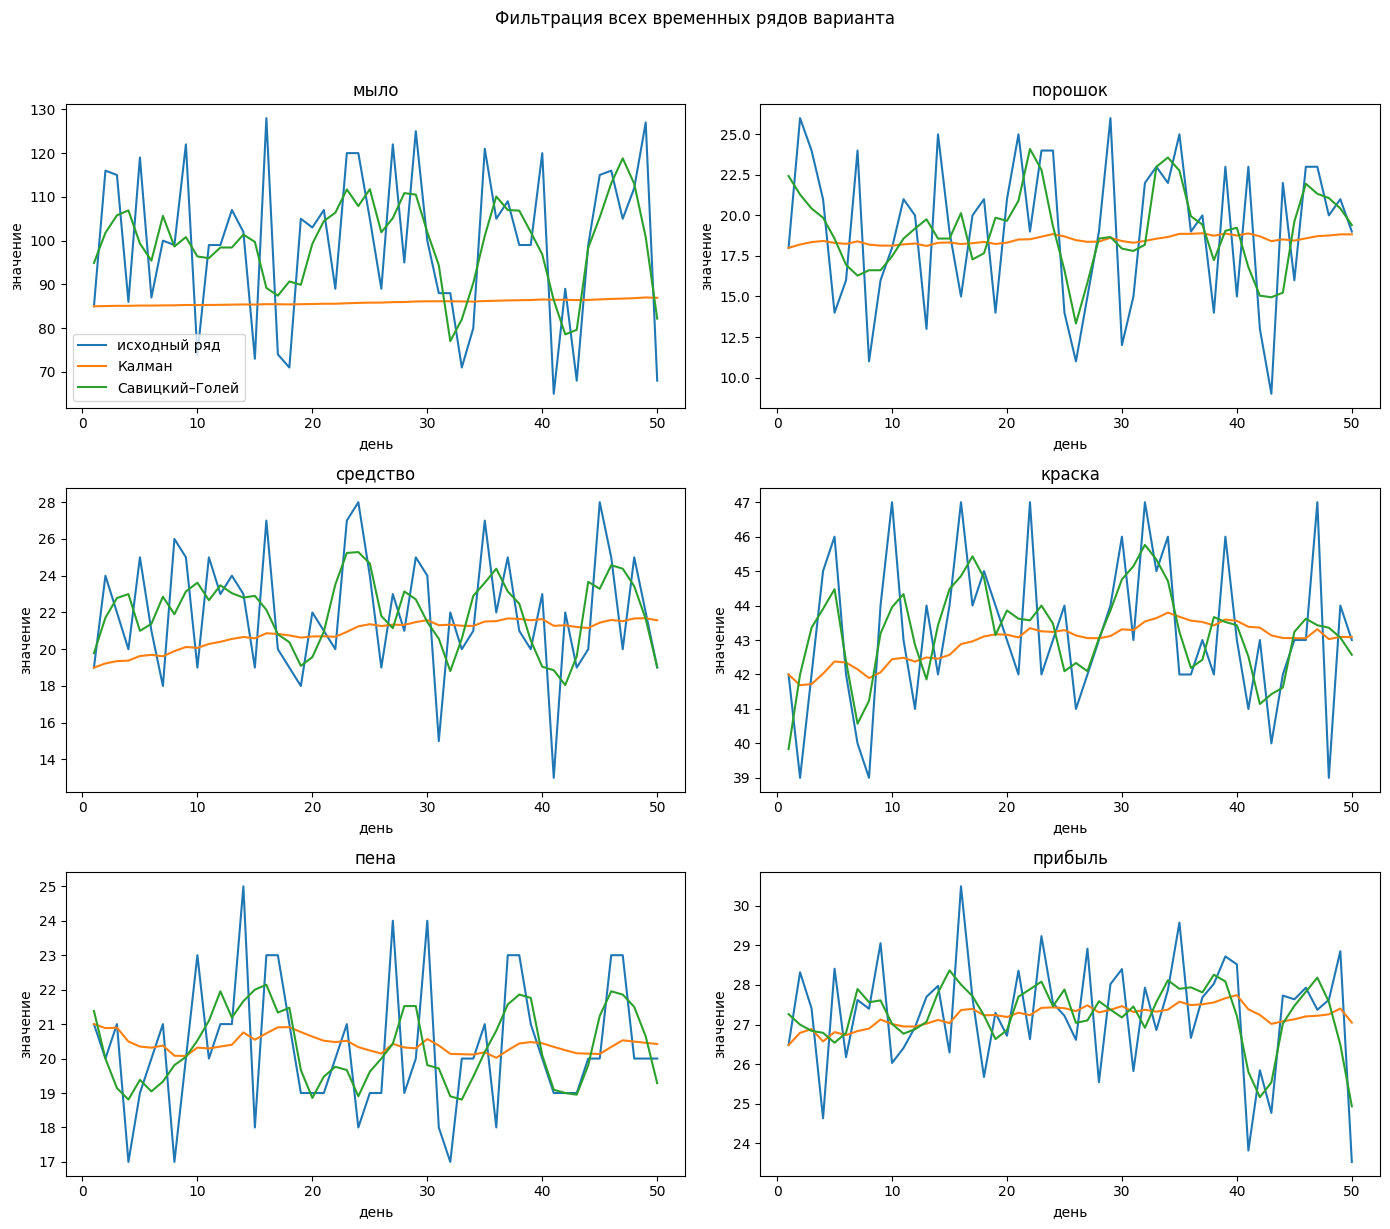

In [52]:
filtered_by_column = {}

for column in value_columns:
    temp = apply_all_filters(selected[column])
    temp.insert(0, "день", selected["день"].values)
    filtered_by_column[column] = temp

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for i, column in enumerate(value_columns):
    frame = filtered_by_column[column]
    ax = axes[i]

    ax.plot(frame["день"], frame["исходный ряд"], label="исходный ряд")
    ax.plot(frame["день"], frame["Калман"], label="Калман")
    ax.plot(frame["день"], frame["Савицкий–Голей"], label="Савицкий–Голей")

    ax.set_title(column)
    ax.set_xlabel("день")
    ax.set_ylabel("значение")

axes[0].legend()
fig.suptitle("Фильтрация всех временных рядов варианта", y=1.02)
fig.tight_layout()
plt.show()


## Вывод по фильтрации

По графикам видно, что все фильтры уменьшают локальные скачки, но делают это по-разному

Экспоненциальное сглаживание получается самым простым и понятным, но оно может запаздывать на резких изменениях. Фильтр Калмана даёт более аккуратную траекторию локального уровня. Фильтр Савицкого–Голея хорошо сохраняет форму пиков, потому что работает через локальный полином. LMS-фильтр сильнее зависит от параметров и от первых точек, но показывает идею адаптивной настройки под сам ряд

In [53]:
metrics_without_original = filter_metrics[filter_metrics["метод"] != "исходный ряд"].copy()
metrics_without_original["score"] = (
    metrics_without_original["снижение шероховатости, %"]
    * metrics_without_original["corr с исходным рядом"]
)

best_balanced = metrics_without_original.sort_values("score", ascending=False).iloc[0]

print(f"Наиболее сбалансированный фильтр по выбранной эвристике: {best_balanced['метод']}.")
print(f"Он снизил шероховатость примерно на {best_balanced['снижение шероховатости, %']:.1f}%")
print(f"и сохранил корреляцию с исходным рядом {best_balanced['corr с исходным рядом']:.3f}.")


Наиболее сбалансированный фильтр по выбранной эвристике: экспоненциальное сглаживание.
Он снизил шероховатость примерно на 73.1%
и сохранил корреляцию с исходным рядом 0.777.


# **4. Анализ данных варианта**

Теперь анализируем сами временные ряды. Здесь нас интересуют не фильтры, а структура данных:

* какие товары продаются стабильнее
* какие товары сильнее связаны с прибылью
* есть ли заметный тренд
* есть ли повторяемость или периодичность
* насколько прибыль зависит от общего количества проданных товаров

In [54]:
descriptive_stats = selected[value_columns].describe().T
descriptive_stats["range"] = descriptive_stats["max"] - descriptive_stats["min"]
descriptive_stats["coef_var"] = descriptive_stats["std"] / descriptive_stats["mean"]

descriptive_stats.sort_values("coef_var", ascending=False)


,count,mean,std,min,25%,50%,75%,max,range,coef_var
порошок,50.0,19.06000,4.469443,9.000,15.000,20.0000,23.0000,26.000,17.000,0.234493
мыло,50.0,99.60000,17.616087,65.000,88.000,100.0000,115.0000,128.000,63.000,0.176868
средство,50.0,22.00000,3.207135,13.000,20.000,22.0000,24.7500,28.000,15.000,0.145779
пена,50.0,20.32000,1.899946,17.000,19.000,20.0000,21.0000,25.000,8.000,0.093501
прибыль,50.0,27.27892,1.401662,23.528,26.514,27.5805,28.0275,30.493,6.965,0.051383
краска,50.0,43.22000,2.131302,39.000,42.000,43.0000,44.0000,47.000,8.000,0.049313


In [55]:
correlation_matrix = selected[value_columns].corr()
correlation_matrix


,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000000,0.122137,0.735814,-0.082404,0.183169,0.778796
порошок,0.122137,1.000000,0.031322,0.005013,0.096228,0.130813
средство,0.735814,0.031322,1.000000,-0.035828,0.150715,0.635759
краска,-0.082404,0.005013,-0.035828,1.000000,0.148575,0.127161
пена,0.183169,0.096228,0.150715,0.148575,1.000000,0.387331
прибыль,0.778796,0.130813,0.635759,0.127161,0.387331,1.000000


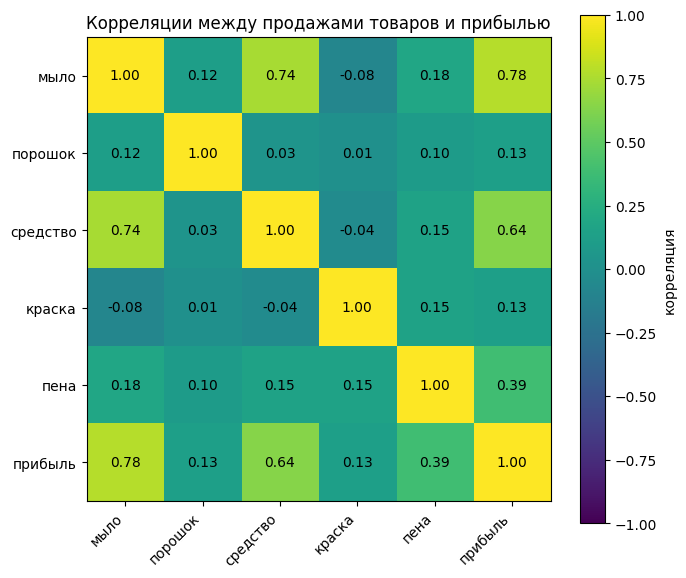

In [56]:
fig, ax = plt.subplots(figsize=(7, 6))

picture = ax.imshow(correlation_matrix, vmin=-1, vmax=1)
ax.set_xticks(range(len(value_columns)))
ax.set_yticks(range(len(value_columns)))
ax.set_xticklabels(value_columns, rotation=45, ha="right")
ax.set_yticklabels(value_columns)

for i in range(len(value_columns)):
    for j in range(len(value_columns)):
        value = correlation_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.colorbar(picture, ax=ax, label="корреляция")
plt.title("Корреляции между продажами товаров и прибылью")
plt.tight_layout()
plt.show()


## Тренд

Для оценки тренда используем простую линейную регрессию по номеру дня. Коэффициент при дне показывает среднее изменение показателя за один день

In [57]:
def estimate_linear_trend(frame, columns):
    x = frame[["день"]]
    rows = []

    for column in columns:
        y = frame[column]

        model = LinearRegression()
        model.fit(x, y)
        prediction = model.predict(x)

        rows.append({
            "ряд": column,
            "наклон за день": model.coef_[0],
            "интерсепт": model.intercept_,
            "R2 линейного тренда": r2_score(y, prediction),
        })

    return pd.DataFrame(rows).sort_values("R2 линейного тренда", ascending=False)


trend_table = estimate_linear_trend(selected, value_columns)
trend_table


,ряд,наклон за день,интерсепт,R2 линейного тренда
5,прибыль,-0.004851,27.402625,0.002545
2,средство,-0.010948,22.279184,0.002476
4,пена,0.005762,20.173061,0.001955
3,краска,0.004754,43.098776,0.001057
0,мыло,-0.013253,99.937959,0.000120
1,порошок,-0.000624,19.075918,0.000004


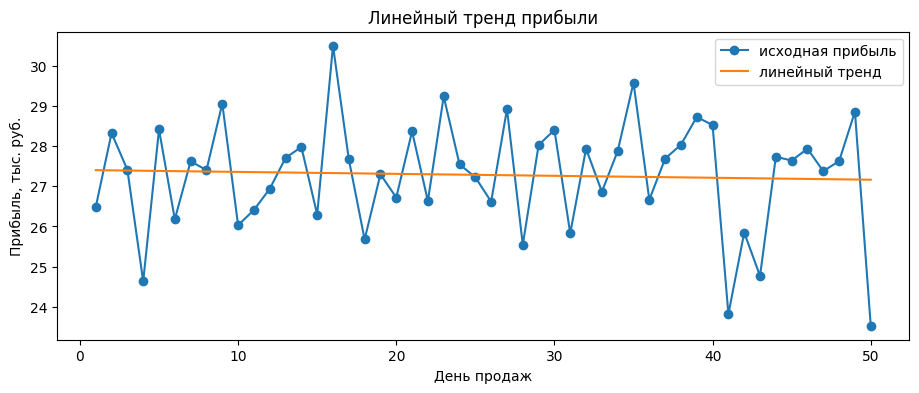

In [58]:
model = LinearRegression()
model.fit(selected[["день"]], selected["прибыль"])
profit_trend = model.predict(selected[["день"]])

plt.figure(figsize=(11, 4))
plt.plot(selected["день"], selected["прибыль"], marker="o", label="исходная прибыль")
plt.plot(selected["день"], profit_trend, label="линейный тренд")
plt.title("Линейный тренд прибыли")
plt.xlabel("День продаж")
plt.ylabel("Прибыль, тыс. руб.")
plt.legend()
plt.show()


## Автокорреляция

Автокорреляция показывает, насколько ряд похож сам на себя при сдвиге на несколько дней. Если на некотором лаге есть высокий пик, это может означать повторяемость с таким периодом

In [59]:
def autocorrelation(values, max_lag=20):
    values = np.array(values, dtype=float)
    values = values - values.mean()
    denominator = np.dot(values, values)

    rows = []

    for lag in range(1, max_lag + 1):
        if lag >= len(values):
            break

        corr = np.dot(values[:-lag], values[lag:]) / denominator
        rows.append({"лаг": lag, "автокорреляция": corr})

    return pd.DataFrame(rows)


acf_profit = autocorrelation(selected["прибыль"], max_lag=20)
acf_profit


,лаг,автокорреляция
0,1,-0.184303
1,2,-0.001583
2,3,-0.063076
3,4,-0.129945
4,5,-0.023584
5,6,-0.152012
6,7,0.168018
7,8,-0.009430
8,9,0.107506
9,10,-0.012864


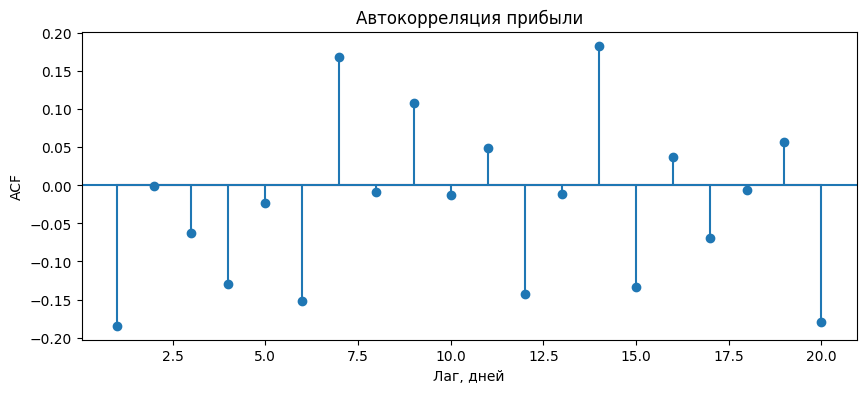

In [60]:
plt.figure(figsize=(10, 4))
plt.stem(acf_profit["лаг"], acf_profit["автокорреляция"])
plt.axhline(0)
plt.title("Автокорреляция прибыли")
plt.xlabel("Лаг, дней")
plt.ylabel("ACF")
plt.show()


## Спектральная оценка периодичности

Ещё один способ искать периодичность - перейти к частотам через дискретное преобразование Фурье. Мы ищем частоту с максимальной мощностью, кроме нулевой частоты, которая отвечает просто за средний уровень ряда

In [61]:
def dominant_period(values):
    values = np.array(values, dtype=float)
    values = values - values.mean()

    spectrum = np.fft.rfft(values)
    freqs = np.fft.rfftfreq(len(values), d=1)

    freqs = freqs[1:]
    power = np.abs(spectrum[1:]) ** 2
    periods = 1 / freqs

    result = pd.DataFrame({
        "frequency": freqs,
        "period_days": periods,
        "power": power,
    })

    result = result[result["period_days"] <= len(values) / 2]
    return result.sort_values("power", ascending=False)


period_table = dominant_period(selected["прибыль"])
period_table.head(8)


,frequency,period_days,power
13,0.28,3.571429,268.188591
22,0.46,2.173913,235.260270
10,0.22,4.545455,186.769988
4,0.10,10.000000,158.872762
20,0.42,2.380952,138.536063
7,0.16,6.250000,133.941916
14,0.30,3.333333,132.288045
17,0.36,2.777778,111.460204


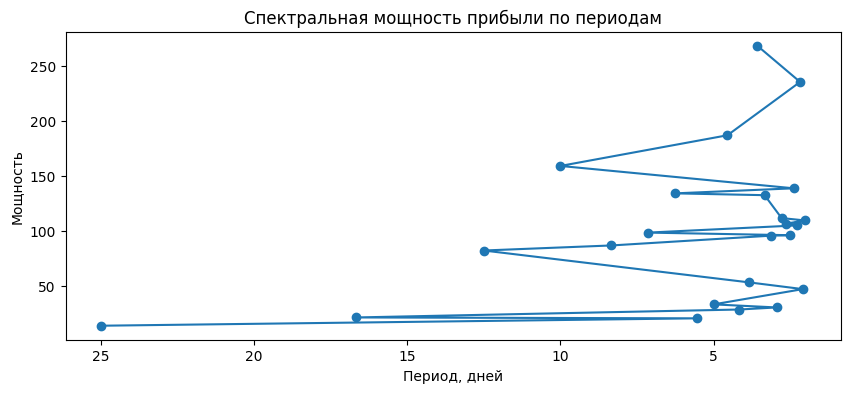

In [62]:
plt.figure(figsize=(10, 4))
plt.plot(period_table["period_days"], period_table["power"], marker="o")
plt.title("Спектральная мощность прибыли по периодам")
plt.xlabel("Период, дней")
plt.ylabel("Мощность")
plt.gca().invert_xaxis()
plt.show()


## Недельный профиль

Так как в продажах часто встречается недельная повторяемость, дополнительно группируем дни по остатку от деления на 7. Это не доказывает сезонность строго, но помогает увидеть, есть ли повторяющиеся недельные пики

In [63]:
weekly_profile = selected.copy()
weekly_profile["день недели"] = (weekly_profile["день"] - 1) % 7 + 1

weekly_summary = weekly_profile.groupby("день недели")[value_columns].mean()
weekly_summary


,мыло,порошок,средство,краска,пена,прибыль
день недели,,,,,,
1,89.000000,17.500000,21.125000,42.625000,19.125000,26.222375
2,113.428571,19.285714,24.571429,43.285714,21.571429,28.702571
3,97.857143,18.714286,21.857143,43.428571,20.857143,27.162857
4,94.857143,20.714286,22.142857,44.714286,19.714286,26.930714
5,101.142857,17.142857,21.142857,43.857143,20.142857,27.429143
6,96.571429,18.571429,21.285714,42.428571,20.428571,26.974429
7,105.857143,21.714286,22.000000,42.285714,20.571429,27.681286


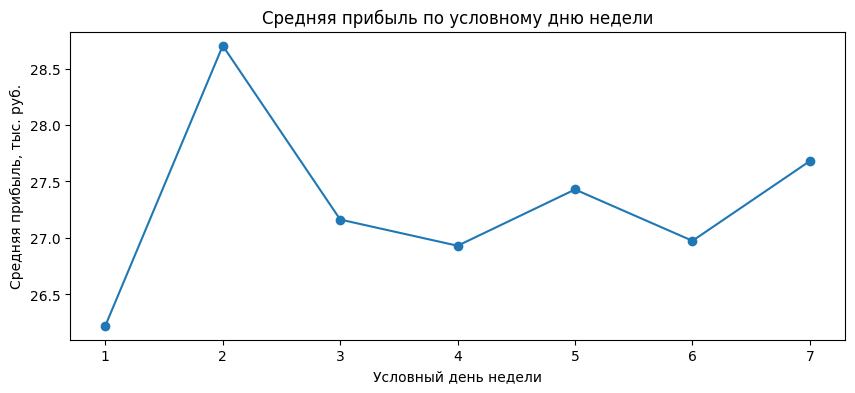

In [64]:
plt.figure(figsize=(10, 4))
plt.plot(weekly_summary.index, weekly_summary["прибыль"], marker="o")
plt.title("Средняя прибыль по условному дню недели")
plt.xlabel("Условный день недели")
plt.ylabel("Средняя прибыль, тыс. руб.")
plt.xticks(range(1, 8))
plt.show()


In [65]:
profit_corr = correlation_matrix["прибыль"].drop("прибыль")
abs_profit_corr = profit_corr.abs().sort_values(ascending=False)

best_corr_column = abs_profit_corr.index[0]
best_corr_value = profit_corr[best_corr_column]

top_period = period_table.iloc[0]
profit_trend_row = trend_table[trend_table["ряд"] == "прибыль"].iloc[0]
most_unstable_column = descriptive_stats["coef_var"].idxmax()

print("Основные выводы по варианту:")
print(f"1. С прибылью сильнее всего связан ряд: {best_corr_column} (corr = {best_corr_value:.3f})")
print(f"2. Линейный наклон прибыли: {profit_trend_row['наклон за день']:.4f} тыс. руб. за день")
print(f"3. R2 линейного тренда прибыли: {profit_trend_row['R2 линейного тренда']:.3f}")
print(f"4. Самый заметный спектральный период прибыли: примерно {top_period['period_days']:.1f} дня")
print(f"5. Наибольший коэффициент вариации у ряда: {most_unstable_column}")


Основные выводы по варианту:
1. С прибылью сильнее всего связан ряд: мыло (corr = 0.779)
2. Линейный наклон прибыли: -0.0049 тыс. руб. за день
3. R2 линейного тренда прибыли: 0.003
4. Самый заметный спектральный период прибыли: примерно 3.6 дня
5. Наибольший коэффициент вариации у ряда: порошок


# **5. Hard-часть: внешний датасет с несколькими датчиками**

Для hard-части возьмём датасет **UCI Air Quality**. Он удобен именно для задачи фильтрации датчиков, потому что содержит:

* показания массива химических сенсоров
* эталонные концентрации загрязнителей от сертифицированного анализатора
* почасовые измерения за длительный период

В качестве пары «датчик — эталон» используем:

* `PT08.S4(NO2)` - сенсор, номинально направленный на NO2
* `NO2(GT)` - эталонная концентрация NO2 от reference analyzer

Идея анализа: отфильтровать сенсорный ряд и проверить, становится ли линейно откалиброванное показание ближе к эталонному NO2. Такой пример хорошо показывает практический смысл фильтрации: сенсор сам по себе шумит и имеет другие единицы измерения, поэтому сначала его надо сгладить, а затем откалибровать

In [66]:
AIR_PATH = Path("AirQualityUCI.csv")

air_raw = pd.read_csv(AIR_PATH, encoding="utf-8-sig")
air_raw = air_raw.dropna(axis=1, how="all")
air_raw = air_raw.dropna(axis=0, how="all")

air_raw.shape


(9357, 15)

In [67]:
air = air_raw.copy()
air = air.replace(-200, np.nan)

air["datetime"] = pd.to_datetime(
    air["Date"].astype(str) + " " + air["Time"].astype(str),
    errors="coerce",
)

hard_columns = ["datetime", "CO(GT)", "PT08.S1(CO)", "NO2(GT)", "PT08.S4(NO2)", "T", "RH"]
hard = air[hard_columns].dropna()
hard = hard.sort_values("datetime").reset_index(drop=True)

hard_sample = hard.head(900).copy()
hard_sample.head()


,datetime,CO(GT),PT08.S1(CO),NO2(GT),PT08.S4(NO2),T,RH
0,2004-03-10 18:00:00,2.6,1360.0,113.0,1692.0,13.6,48.9
1,2004-03-10 19:00:00,2.0,1292.0,92.0,1559.0,13.3,47.7
2,2004-03-10 20:00:00,2.2,1402.0,114.0,1555.0,11.9,54.0
3,2004-03-10 21:00:00,2.2,1376.0,122.0,1584.0,11.0,60.0
4,2004-03-10 22:00:00,1.6,1272.0,116.0,1490.0,11.2,59.6


In [68]:
def zscore(values):
    values = np.array(values, dtype=float)
    return (values - values.mean()) / values.std(ddof=1)


sensor_raw = hard_sample["PT08.S4(NO2)"].to_numpy(dtype=float)
no2_reference = hard_sample["NO2(GT)"].to_numpy(dtype=float)

sensor_exp = exponential_smoothing(sensor_raw, alpha=0.5)
sensor_kalman = kalman_filter_1d(sensor_raw, process_variance=1000.0)
sensor_savgol = savgol_smoothing(sensor_raw, window_length=7, polyorder=2)
sensor_lms = lms_adaptive_filter(sensor_raw, n_taps=8, mu=0.55)

sensor_filters = pd.DataFrame({
    "datetime": hard_sample["datetime"],
    "NO2 эталон, z-score": zscore(no2_reference),
    "сенсор raw, z-score": zscore(sensor_raw),
    "сенсор экспоненциально, z-score": zscore(sensor_exp),
    "сенсор Калман, z-score": zscore(sensor_kalman),
    "сенсор Савицкий–Голей, z-score": zscore(sensor_savgol),
    "сенсор LMS, z-score": zscore(sensor_lms),
})

sensor_filters.head()


,datetime,"NO2 эталон, z-score","сенсор raw, z-score","сенсор экспоненциально, z-score","сенсор Калман, z-score","сенсор Савицкий–Голей, z-score","сенсор LMS, z-score"
0,2004-03-10 18:00:00,0.385762,0.315124,0.366093,0.483589,0.195449,0.259257
1,2004-03-10 19:00:00,-0.270307,-0.139667,0.102208,0.444326,0.076532,0.055685
2,2004-03-10 20:00:00,0.417003,-0.153344,-0.037670,0.390285,-0.072954,-0.052223
3,2004-03-10 21:00:00,0.666934,-0.054180,-0.050071,0.343582,-0.253009,-0.061790
4,2004-03-10 22:00:00,0.479486,-0.375610,-0.242775,0.238676,-0.428293,-0.210451


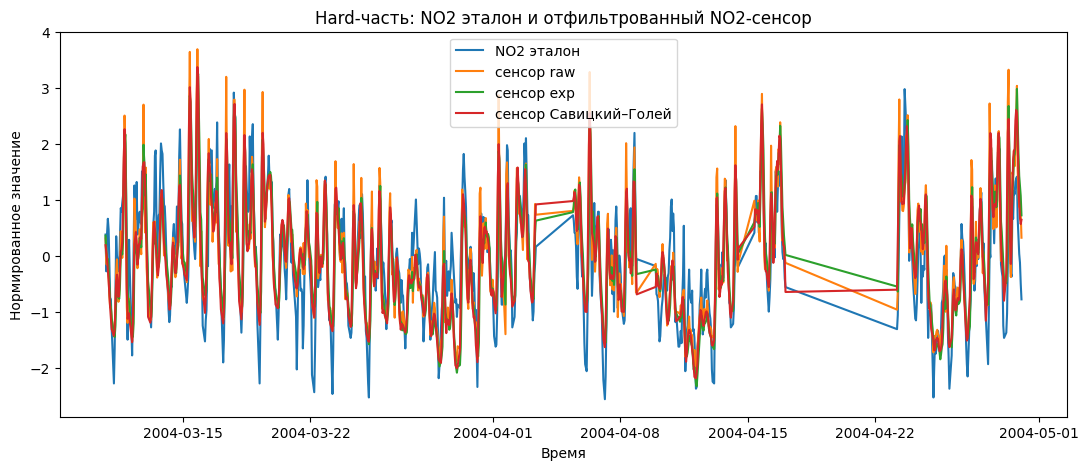

In [69]:
plt.figure(figsize=(13, 5))
plt.plot(sensor_filters["datetime"], sensor_filters["NO2 эталон, z-score"], label="NO2 эталон")
plt.plot(sensor_filters["datetime"], sensor_filters["сенсор raw, z-score"], label="сенсор raw")
plt.plot(sensor_filters["datetime"], sensor_filters["сенсор экспоненциально, z-score"], label="сенсор exp")
plt.plot(sensor_filters["datetime"], sensor_filters["сенсор Савицкий–Голей, z-score"], label="сенсор Савицкий–Голей")

plt.title("Hard-часть: NO2 эталон и отфильтрованный NO2-сенсор")
plt.xlabel("Время")
plt.ylabel("Нормированное значение")
plt.legend()
plt.show()


## Проверка через калибровку сенсора

Сенсор и эталон имеют разные единицы измерения, поэтому напрямую считать ошибку между ними нельзя. Сначала обучим простую линейную калибровку:

$$
NO2_{GT} \approx a \cdot sensor + b
$$

Затем сравним, какой вход для такой калибровки даёт меньшую ошибку: сырой сенсор или отфильтрованный сенсор

In [70]:
def calibration_metrics(sensor_values, target_values, train_share=0.7):
    split = int(len(sensor_values) * train_share)

    x_train = sensor_values[:split].reshape(-1, 1)
    y_train = target_values[:split]

    x_test = sensor_values[split:].reshape(-1, 1)
    y_test = target_values[split:]

    model = LinearRegression()
    model.fit(x_train, y_train)

    prediction = model.predict(x_test)

    return {
        "a": model.coef_[0],
        "b": model.intercept_,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R2": r2_score(y_test, prediction),
    }


hard_methods = {
    "raw sensor": sensor_raw,
    "exponential sensor": sensor_exp,
    "Kalman sensor": sensor_kalman,
    "Savitzky-Golay sensor": sensor_savgol,
    "LMS sensor": sensor_lms,
}

hard_metrics = []

for name, values in hard_methods.items():
    row = calibration_metrics(values, no2_reference)
    row["ряд"] = name
    row["corr с NO2(GT)"] = np.corrcoef(values, no2_reference)[0, 1]
    hard_metrics.append(row)

hard_metrics = pd.DataFrame(hard_metrics)
hard_metrics = hard_metrics[["ряд", "corr с NO2(GT)", "MAE", "RMSE", "R2", "a", "b"]]

hard_metrics.sort_values("RMSE")


,ряд,corr с NO2(GT),MAE,RMSE,R2,a,b
1,exponential sensor,0.823567,15.068842,19.170627,0.675366,0.110812,-74.185689
3,Savitzky-Golay sensor,0.818435,14.575078,19.561959,0.661977,0.101454,-59.177255
0,raw sensor,0.815130,14.569630,19.703628,0.657063,0.092184,-44.367442
4,LMS sensor,0.741109,17.449234,22.024145,0.571531,0.071218,-11.355274
2,Kalman sensor,0.629247,19.675169,24.737610,0.459448,0.113653,-78.991668


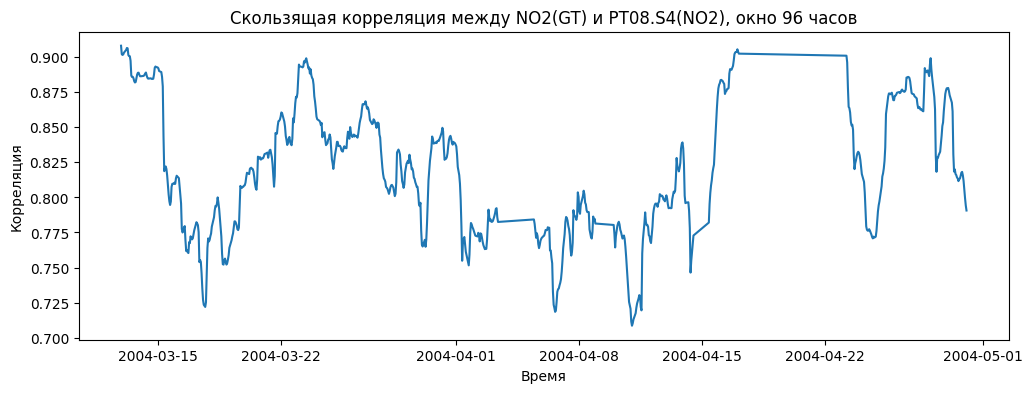

Средняя скользящая корреляция: 0.820
Минимальная скользящая корреляция: 0.709
Максимальная скользящая корреляция: 0.908


In [71]:
rolling_corr = hard_sample["NO2(GT)"].rolling(window=96, min_periods=48).corr(
    hard_sample["PT08.S4(NO2)"]
)

plt.figure(figsize=(12, 4))
plt.plot(hard_sample["datetime"], rolling_corr)
plt.title("Скользящая корреляция между NO2(GT) и PT08.S4(NO2), окно 96 часов")
plt.xlabel("Время")
plt.ylabel("Корреляция")
plt.show()

print(f"Средняя скользящая корреляция: {rolling_corr.mean():.3f}")
print(f"Минимальная скользящая корреляция: {rolling_corr.min():.3f}")
print(f"Максимальная скользящая корреляция: {rolling_corr.max():.3f}")


In [72]:
best_hard = hard_metrics.sort_values("RMSE").iloc[0]
raw_hard = hard_metrics[hard_metrics["ряд"] == "raw sensor"].iloc[0]

rmse_delta = raw_hard["RMSE"] - best_hard["RMSE"]
rmse_delta_percent = 100 * rmse_delta / raw_hard["RMSE"]

print("Вывод по hard-части:")
print(f"1. Лучший вариант по RMSE после линейной калибровки: {best_hard['ряд']}")
print(f"2. RMSE сырого сенсора: {raw_hard['RMSE']:.3f}")
print(f"3. RMSE лучшего варианта: {best_hard['RMSE']:.3f}")
print(f"4. Улучшение RMSE относительно сырого сенсора: {rmse_delta:.3f}, то есть примерно {rmse_delta_percent:.1f}%")
print(f"5. Корреляция лучшего варианта с эталоном NO2(GT): {best_hard['corr с NO2(GT)']:.3f}")
print("6. Фильтрация здесь полезна: она немного снижает шум сенсора и помогает простой калибровке.")


Вывод по hard-части:
1. Лучший вариант по RMSE после линейной калибровки: exponential sensor
2. RMSE сырого сенсора: 19.704
3. RMSE лучшего варианта: 19.171
4. Улучшение RMSE относительно сырого сенсора: 0.533, то есть примерно 2.7%
5. Корреляция лучшего варианта с эталоном NO2(GT): 0.824
6. Фильтрация здесь полезна: она немного снижает шум сенсора и помогает простой калибровке.


# **Итоговый вывод**

В работе были реализованы и сравнены несколько подходов к фильтрации временных рядов

Главный смысл фильтрации здесь не в том, чтобы «исправить» данные вручную, а в том, чтобы выделить более устойчивую динамику. Для продаж это помогает увидеть общий уровень прибыли и поведение товаров без случайных дневных скачков. Для сенсорных данных это может приблизить шумный датчик к более стабильной траектории, которую затем можно использовать для калибровки

По данным продаж наиболее интерпретируемыми оказались фильтр Калмана и фильтр Савицкого–Голея: первый хорошо описывает скрытый локальный уровень, второй хорошо сохраняет форму локальных пиков. LMS-фильтр показан как адаптивный метод: он полезен, когда свойства ряда могут меняться во времени, но требует более аккуратной настройки параметров